# Limpieza de datos irrelevantes y escalamiento de variables

#### Importar librerías y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Carga del dataset original
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Visualizar primeras filas del df
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#### Identificación y Eliminación de Variables Irrelevantes

Según la documentación técnica, la variable duration es altamente predictiva pero irrelevante para un modelo realista, ya que solo se conoce después de que la llamada termina. Mantenerla sería una falta de ética profesional y técnica

In [3]:
# Verificamos la presencia de la variable antes de eliminarla
print(f"Columnas originales: {df.shape[1]}")

# Eliminamos 'duration' por integridad del modelo y ética en los datos
df_reducido = df.drop(columns=['duration'])

# Eliminamos 'mora' (default) ya que menos del 0.01% de los datos tiene como "sí", haciéndolo irrelevante
df_reducido = df_reducido.drop(columns=['default'])

# Justificación: Un modelo realista no puede usar información que no existe 
# antes de la toma de decisión (realizar la llamada).
print(f"Columnas después de la limpieza: {df_reducido.shape[1]}")

Columnas originales: 21
Columnas después de la limpieza: 19


#### Análisis de Outliers

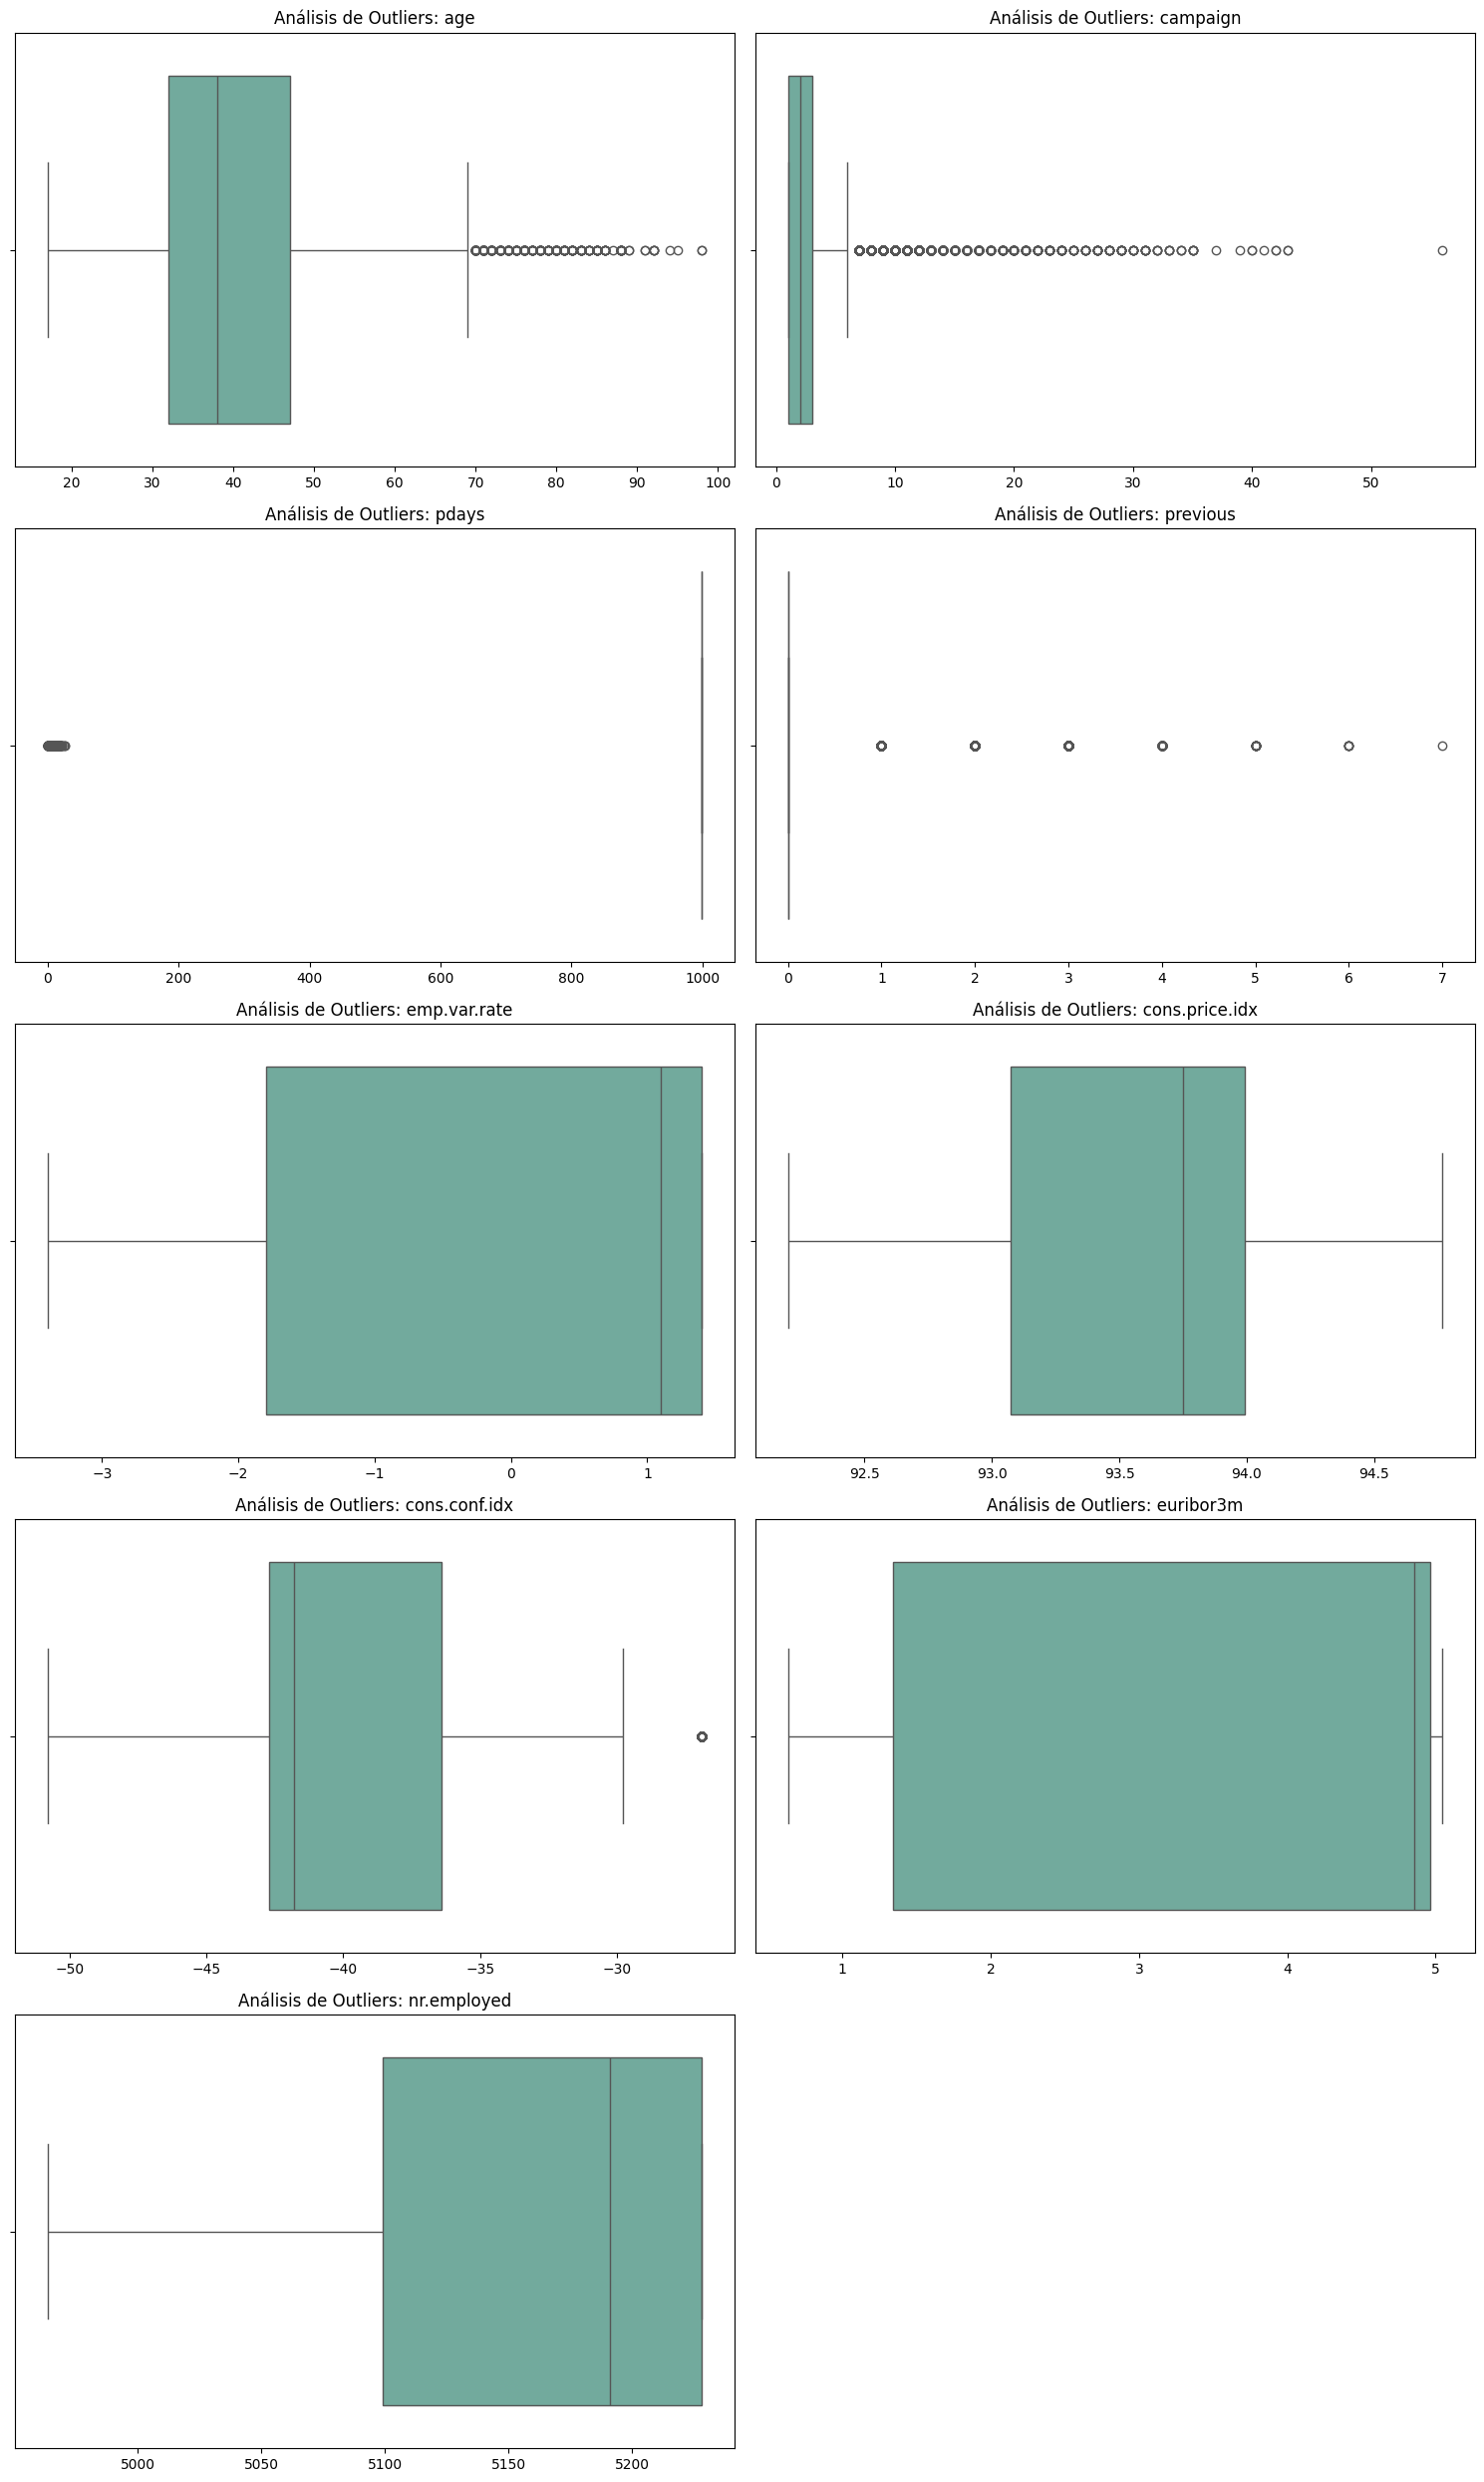

In [5]:
# 1. Identificar todas las columnas numéricas del dataframe reducido
columnas_numericas = df_reducido.select_dtypes(include=['int64', 'float64']).columns

# 2. Configurar el área de dibujo (subtramas)
# Calculamos cuántas filas necesitamos para mostrar los gráficos de 2 en 2
n_cols = 2
n_rows = (len(columnas_numericas) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# 3. Ciclo for para generar un boxplot por cada variable numérica
for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=df_reducido[col], ax=axes[i], color='#69b3a2')
    axes[i].set_title(f'Análisis de Outliers: {col}', fontsize=12)
    axes[i].set_xlabel('')

# 4. Limpieza de gráficos vacíos (si el número de columnas es impar)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Escalamiento de Variables numéricas

Se utiliza StandardScaler para transformar las variables numéricas de modo que tengan una media de 0 y una desviación estándar de 1. Esto asegura que variables con rangos grandes (como nr.employed) no dominen injustamente sobre variables con rangos pequeños (como euribor3m) durante el entrenamiento del modelo.

In [6]:
# Definimos las columnas numéricas que requieren escalamiento
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 
                'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Inicializamos el escalador estándar
scaler = StandardScaler()

# Aplicamos el escalamiento y sobreescribimos en el dataframe
df_reducido[numeric_cols] = scaler.fit_transform(df_reducido[numeric_cols])

# Mostramos los resultados escalados (ahora centrados en 0)
df_reducido[numeric_cols].head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
1,1.628993,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
2,-0.290186,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
3,-0.002309,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168
4,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168


#### Verificación de la Integridad de datos


In [7]:
# Resumen estadístico post-escalamiento para confirmar media ~ 0 y std ~ 1
df_reducido[numeric_cols].describe().round(2)

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.21,-0.57,-5.15,-0.35,-2.22,-2.37,-2.22,-1.72,-2.82
25%,-0.77,-0.57,0.20,-0.35,-1.20,-0.86,-0.47,-1.31,-0.94
50%,-0.19,-0.20,0.20,-0.35,0.65,0.30,-0.28,0.71,0.33
75%,0.67,0.16,0.20,-0.35,0.84,0.72,0.89,0.77,0.85
max,5.56,19.29,0.20,13.79,0.84,2.06,2.94,0.82,0.85
